<h1>Model multinomijalne logističke regresije</h1>
<h2>Uvođenje potrebnih paketa</h2>

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model
from sklearn import metrics
from sklearn import model_selection
from sklearn import preprocessing
np.random.seed(7)

In [31]:
import joblib

<h2>Učitavanje pretprocesiranih podataka</h2>

In [32]:
data = pd.read_csv("preprocessed_data.csv", index_col = 0)

In [33]:
data.head()

,Education Level,Finance,Science,Business,Computer Science,Arts,Psychology,Commerce,Engineering,Counseling,...,Marketing,Tally ERP,AWS Certified,Mental Health Basics,Digital Marketing,CFA Level 1,Creative Writing,Google Data Analytics,CGPA/Percentage,Recommended Career
0,2,1,0,0,0,0,0,0,0,1,...,0,1,0,0,0,0,0,0,67,Business Analyst
1,1,0,1,0,0,0,0,0,0,0,...,0,0,1,0,0,0,0,0,67,Software Engineer
2,3,0,0,1,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,90,Financial Analyst
3,2,0,0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,75,Clerk
4,0,0,0,1,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,83,Sales Assistant


In [34]:
data.describe()

,Education Level,Finance,Science,Business,Computer Science,Arts,Psychology,Commerce,Engineering,Counseling,...,Python,Marketing,Tally ERP,AWS Certified,Mental Health Basics,Digital Marketing,CFA Level 1,Creative Writing,Google Data Analytics,CGPA/Percentage
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,...,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000
mean,1.99100,0.131800,0.113600,0.126800,0.121800,0.120800,0.131400,0.120200,0.133600,0.197200,...,0.206200,0.198400,0.128800,0.127600,0.134800,0.126000,0.1232,0.113600,0.126800,77.479800
std,1.40816,0.338307,0.317357,0.332782,0.327087,0.325927,0.337871,0.325228,0.340256,0.397924,...,0.404616,0.398835,0.335012,0.333677,0.341544,0.331883,0.3287,0.317357,0.332782,10.396288
min,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,60.000000
25%,1.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,68.000000
50%,2.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,77.000000
75%,3.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,0.000000,87.000000
max,4.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,1.000000,95.000000


In [35]:
target = 'Recommended Career'

<h2>Izdvajanje atributa</h2>

In [36]:
x = data.drop(target, axis=1)

In [37]:
x.shape

(5000, 27)

<h2>Izdvajanje i label enkodovanje ciljne promenljive</h2>

In [38]:
target_names = data[target].unique()

y = data[target]

label_encoder = preprocessing.LabelEncoder()
y_encoded = label_encoder.fit_transform( data[target] )

y_encoded

array([ 0, 11,  3, ...,  3, 11,  1], shape=(5000,))

<h2>Podela podataka na skupove za treniranje i testiranje i standardizacija</h2>
U opštem slučaju se vrši podela podataka na skup nad kojim će model trenirati(trening skup), skup nad kojim će se vršiti evaluacija modela u cilju izbora optimalnih parametara(validacioni skup) i skup koji će se koristiti za evaluaciju modela i davanje konačne ocene tog modela(test skup), ali kako za model logističke regresije nismo podešavali metaparametre skup za validaciju nam nije bio potreban. Podela se vrši pomoću funkcije train_test_split pri čemu uzimamo trećinu podataka za skup za testiranje. Takođe vodimo računa o stratifikaciji da bi udeo klasa ciljne promenljive u skupu za treniranje i testiranje bio procentualno jednak. Parametar random_state postavljamo na vrednost 7 kako bi se model mogao reprodukovati.

In [39]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(x, y_encoded, test_size=0.33, stratify=y, random_state = 7)
scaler = preprocessing.StandardScaler()
scaler.fit(x_train)
x_train = scaler.transform(x_train)
x_test = scaler.transform(x_test)

<h2>Pravljenje i treniranje modela</h2>

Pravljenje modela

In [40]:
model = linear_model.LogisticRegression()

Treniranje modela na trening skupu

In [41]:
model.fit(x_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


<h2>Evaluacija modela</h2>

Dobijanje vrednosti predviđanja modela za podatke iz test skupa

In [42]:
y_test_predicted = model.predict(x_test)

In [43]:
print(y_test_predicted)

[ 8 10  1 ...  1  3  2]


Predviđanja modela nam daju vrednost label enkodovane klase ciljne promenljive čiju početnu vrednost možemo dobiti na sledeći način

In [44]:
y_test_predicted_strings = label_encoder.inverse_transform(y_test_predicted)
y_test_predicted_strings

array(['Research Scientist', 'School Counselor', 'Clerk', ..., 'Clerk',
       'Financial Analyst', 'Data Entry Operator'],
      shape=(1650,), dtype=object)

Tačnost modela na trening skupu. Tačnost modela predstavlja procenat tačno predviđenih klasa u odnosu na ukupan broj klasa ciljne promenljive

In [45]:
model.score(x_train, y_train)

0.14238805970149254

Tačnost modela na test skupu

In [46]:
model.score(x_test, y_test)

0.08060606060606061

Na osnovu datih rezultata zaključujemo da model logističke regresije nije mogao da nauči zavisnosti atributa i ciljne promenljive, ukoliko one uopšte postoje, kao i da su predikcije ovog modela gore od predikcija nasumičnog modela (modela koji uopšte ne uzima u obzir atribute) koji bi tačnu klasu tačno predvideo sa verovatnoćom 1/12&#x2248;0.083 (jer ciljna promenljiva ima 12 klasa)

U nastavku je prikazana matrica konfuzije za dati model. Matrica konfuzije predstavlja matricu čiji element u i-toj vrsti i j-toj koloni predstavlja broj predviđanja modela za instancu čija je prava klasa klasa i, a za koju je model predvideo klasu j. Idealna matrica konfuzije je dijagonalna matrica

In [47]:
metrics.confusion_matrix(y_test, y_test_predicted)

array([[ 3, 23, 12,  6, 12,  2, 20,  7, 20,  5, 16,  4],
       [11, 27, 11,  4, 11,  6, 17,  9, 17,  1, 25,  4],
       [ 6, 21, 12,  9, 12,  7, 15,  3, 18,  9, 17,  7],
       [ 9, 18, 14, 13,  9,  4, 13,  8, 16,  6, 18,  8],
       [ 6, 23, 12,  7, 10,  6, 16,  7, 11,  7, 27,  4],
       [ 6, 27, 10,  6, 11,  3, 14, 10, 19,  6, 18, 12],
       [ 8, 15,  8,  6,  8,  9, 19, 13, 15, 10, 19, 13],
       [ 7, 24,  9,  9, 11,  2, 27,  8, 16,  4, 13,  4],
       [11, 30,  8,  9,  9,  2, 17,  7, 11, 10, 14, 10],
       [ 8, 15, 16,  4,  7,  2, 24,  7, 18,  4, 23,  8],
       [11, 21, 11,  5,  9,  3, 18, 11, 17, 11, 16,  5],
       [ 6, 16, 11, 12, 12,  8, 11, 14, 14, 11, 16,  7]])

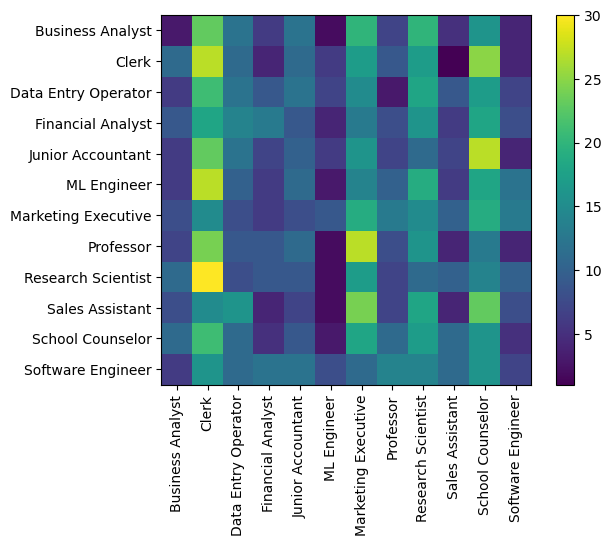

In [48]:
classes_for_display = label_encoder.inverse_transform(range(0, 12))
plt.imshow(metrics.confusion_matrix(y_test, y_test_predicted))
plt.xticks(range(0,  12), labels = classes_for_display, rotation='vertical')
plt.yticks(range(0,  12), labels = classes_for_display)
plt.colorbar()
plt.show()

Na osnovu matrice konfuzije dodatno potvrđujemo da model nije naučio zavisnost između atributa i ciljne promenljive

U nastavku prikazujemo i klasifikacioni izveštaj koji nam pokazuje vrednosti nekih mera pomoću kojih se model može evaluirati po klasama ciljne promenljive. Preciznost predstavlja udeo tačno predviđenih pozitivnih klasa od ukupnog broja klasa za koje je model predvideo pozitivnu klasu. Odziv predstavlja udeo tačno predviđenih pozitivnih klasa u odnosu na ukupan broj pozitivnih klasa. Preciznost i odziv se ne koriste pojedinačno, pa se često radi jednostavnosti kombinuju u jednu meru - F1 meru. F1 mera predstavlja harmonijsku sredinu preciznosti i odziva.

In [49]:
print(metrics.classification_report(y_test, y_test_predicted))

              precision    recall  f1-score   support

           0       0.03      0.02      0.03       130
           1       0.10      0.19      0.13       143
           2       0.09      0.09      0.09       136
           3       0.14      0.10      0.12       136
           4       0.08      0.07      0.08       136
           5       0.06      0.02      0.03       142
           6       0.09      0.13      0.11       143
           7       0.08      0.06      0.07       134
           8       0.06      0.08      0.07       138
           9       0.05      0.03      0.04       136
          10       0.07      0.12      0.09       138
          11       0.08      0.05      0.06       138

    accuracy                           0.08      1650
   macro avg       0.08      0.08      0.08      1650
weighted avg       0.08      0.08      0.08      1650



<h2>Evaluacija modela pomoću unakrsne validacije</h2>
Kako veličina skupa podataka nije mnogo velika za davanje bolje ocene modela logističke regresije koristili smo i unakrsnu validaciju pomoću funkcije cross_val_score iz paketa model_selection

In [50]:
model1 = linear_model.LogisticRegression(max_iter=1000)

In [51]:
scores = model_selection.cross_val_score(model1, x, y, cv=10, scoring='accuracy')
scores

C:\Users\nikol\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\nikol\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please als

array([0.098, 0.076, 0.092, 0.09 , 0.11 , 0.062, 0.086, 0.074, 0.078,
       0.086])

In [52]:
scores.mean()

np.float64(0.08519999999999998)

Iako je ocena tačnosti modela za nijansu veća, model je idalje jako loš

<h2>Čuvanje modela</h2>

In [53]:
joblib.dump(label_encoder, 'Models/Multinomial logistic regression/label_encoder.pkl')

['Models/Multinomial logistic regression/label_encoder.pkl']

In [54]:
joblib.dump(scaler, 'Models/Multinomial logistic regression/standard_scaler.pkl')

['Models/Multinomial logistic regression/standard_scaler.pkl']

In [55]:
joblib.dump(model, 'Models/Multinomial logistic regression/model.pkl')

['Models/Multinomial logistic regression/model.pkl']

In [56]:
joblib.dump(model1, 'Models/Multinomial logistic regression/model1.pkl')

['Models/Multinomial logistic regression/model1.pkl']